In [ ]:
# import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# stock to simulate
TICKER = 'PLTR'
START_DATE = '2024-01-01'
END_DATE = '2025-12-01'


In [ ]:
## data acquistion 4
def get_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, progress=False)
    # Use Close to account for dividends/splits if Adj Close is not available
    prices = data['Close']
    return prices

stock_prices = get_data(TICKER, START_DATE, END_DATE)

/tmp/ipython-input-2676427795.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end, progress=False)


In [ ]:
## calculate log  return
log_returns =np.log(1 + stock_prices.pct_change())


In [ ]:
## parameter estimation
u = log_returns.mean()
var = log_returns.var()
drift = u  - (0.5 * var)
stdev = log_returns.std()

# Extract scalar values for printing and calculate annual_vol
daily_drift_val = drift.item()
daily_stdev_val = stdev.item()
annual_vol = daily_stdev_val * np.sqrt(252)

print(f"--- Parameters for {TICKER} ---")
print(f"Daily Drift: {daily_drift_val:.6f}")
print(f"Daily Volatility: {daily_stdev_val:.6f}")
print(f"Annualized Volatility: {annual_vol:.2%}")

--- Parameters for PLTR ---
Daily Drift: 0.004006
Daily Volatility: 0.040847
Annualized Volatility: 64.84%


In [ ]:
annual_drift = drift*366
annual_vol =stdev*np.sqrt(366)


In [ ]:
def simulate_gbm(last_price, drift, stdev, days, simulations):
    # Create a random component (Z) following a standard normal distribution
    # Shape: (days, simulations)
    Z = norm.ppf(np.random.rand(days, simulations))

    # Calculate daily returns using the GBM formula
    # daily_returns = exp(drift + sigma * Z)
    daily_returns = np.exp(drift + stdev * Z)

    # Initialize price paths matrix
    price_paths = np.zeros_like(daily_returns)
    price_paths[0] = last_price

    # Accumulate returns over time
    for t in range(1, days):
        price_paths[t] = price_paths[t-1] * daily_returns[t]

    return price_paths

NameError: name 'price_paths' is not defined

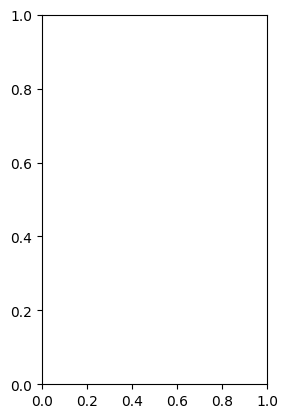

In [ ]:
## viaualization & observation
plt.subplot(1, 2, 1)
plt.plot(price_paths)
plt.title(f'Geometric Brownian Motion: {NUM_SIMULATIONS} Simulations for {TICKER}')
plt.xlabel('Days into Future')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)


In [ ]:
# Define simulation parameters
NUM_SIMULATIONS = 1000
DAYS = 252 # Simulating for one year of trading days

In [ ]:
# Get the last closing price from the historical data
last_price = stock_prices.iloc[-1].item()

# Run the Monte Carlo simulation
price_paths = simulate_gbm(last_price, daily_drift_val, daily_stdev_val, DAYS, NUM_SIMULATIONS)

print(f"Generated {NUM_SIMULATIONS} price paths over {DAYS} days.")
print(f"Last known price: {last_price:.2f}")

Generated 1000 price paths over 252 days.
Last known price: 168.45


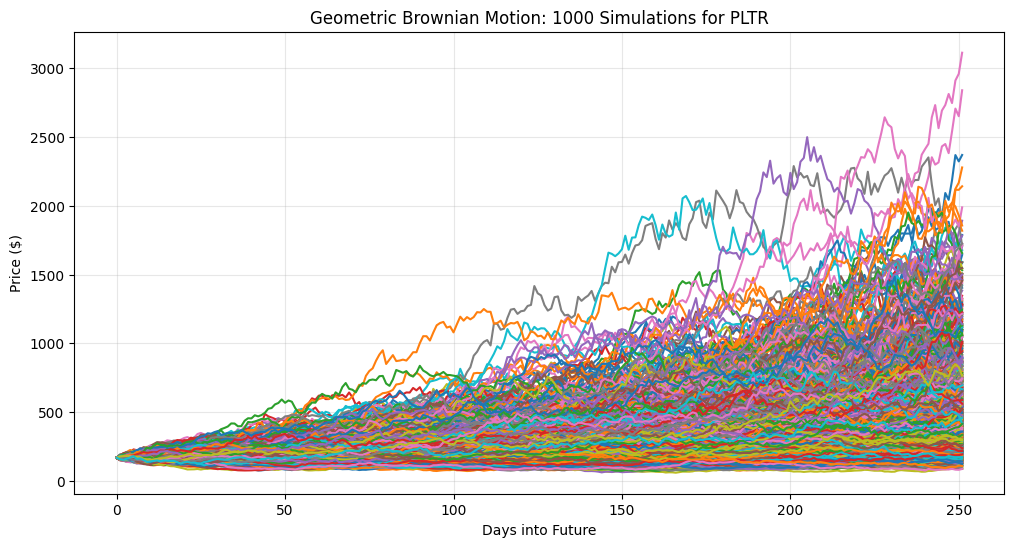

In [ ]:
## visualization & observation
plt.figure(figsize=(12, 6))
plt.plot(price_paths)
plt.title(f'Geometric Brownian Motion: {NUM_SIMULATIONS} Simulations for {TICKER}')
plt.xlabel('Days into Future')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

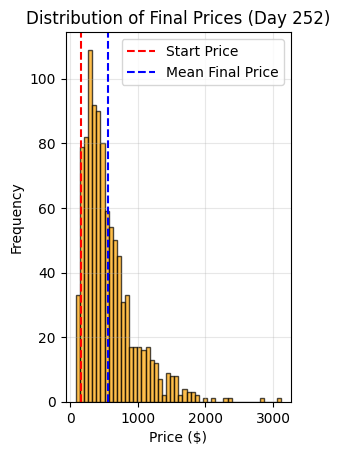

In [ ]:
## distribution of places
plt.subplot(1, 2, 2)
final_prices = price_paths[-1]
plt.hist(final_prices, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(x=last_price, color='red', linestyle='--', label='Start Price')
plt.axvline(x=np.mean(final_prices), color='blue', linestyle='--', label='Mean Final Price')
plt.title(f'Distribution of Final Prices (Day {DAYS})')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# mean final price
mean_final_price = np.mean(final_prices)
expected_return = (mean_final_price - last_price) / last_price

# Value at Risk (VaR) at 95% confidence
# This means: "We are 95% confident the price will not drop below X"
var_95 = np.percentile(final_prices, 5)

print(f"--- Simulation Results ({DAYS} Days) ---")
print(f"Starting Price: ${last_price:.2f}")
print(f"Expected Final Price (Mean): ${mean_final_price:.2f}")
print(f"Expected Return: {expected_return:.2%}")
print(f"Value at Risk (95%): ${var_95:.2f} (Bottom 5% outcome)")

--- Simulation Results (252 Days) ---
Starting Price: $168.45
Expected Final Price (Mean): $566.72
Expected Return: 236.43%
Value at Risk (95%): $155.59 (Bottom 5% outcome)


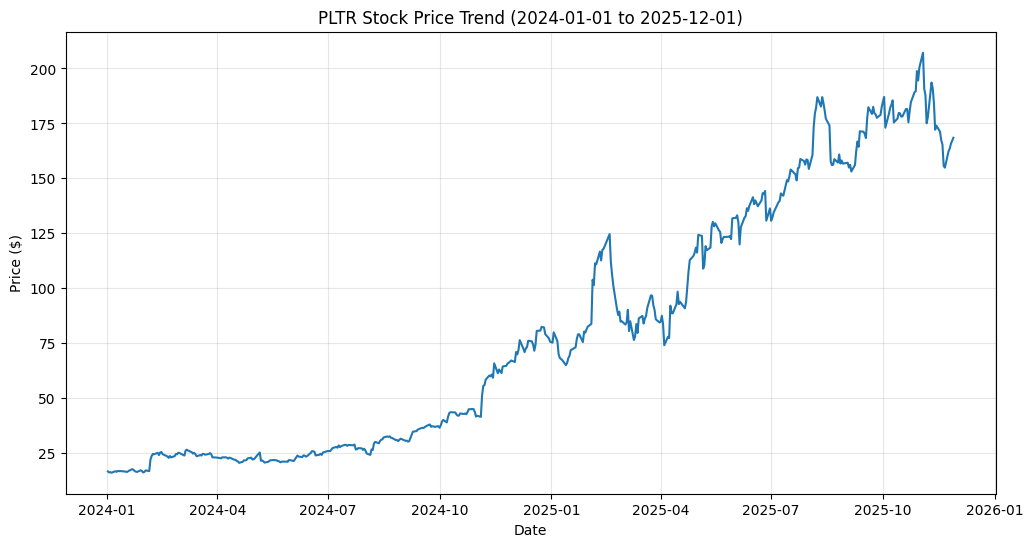

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(stock_prices.index, stock_prices.values)
plt.title(f'{TICKER} Stock Price Trend ({START_DATE} to {END_DATE})')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()